# Atmospheric neutrinos from a measured atmosphere

### AIRS satellite temperatures → MCEq → the IceCube muon-neutrino rate

A pion or kaon made by a cosmic ray either decays into a neutrino or hits a
nucleus first, and which one wins depends on the density of the air around it.
Warm air is thin, mesons decay, and the neutrino rate goes up. So a neutrino
telescope cares what the weather was doing 20 km overhead.

This notebook fetches one week of NASA AIRS satellite temperatures, turns them
into the CSV table MCEq reads, and computes the muon-neutrino rate at IceCube.
It assumes you have used neither AIRS nor MCEq before.

```bash
pip install MCEq requests xarray "numpy>=2" netcdf4 matplotlib cartopy
pip install 'git+https://github.com/afedynitch/nrlmsis2.1'   # for Part 8 only
```

You also need a free [Earthdata Login](https://urs.earthdata.nasa.gov), with
the *NASA GESDISC DATA ARCHIVE* application approved under Applications →
Authorized Apps. Downloads total about 20 MB and are cached, so a second run is
fast. The whole notebook runs in a few minutes.

The grids here are deliberately coarse so that everything stays quick. Where a
setting trades detail for speed the cell says so, and says what to raise.

In [1]:
import datetime
import gzip
import hashlib
import time
import hashlib
import netrc
import os
import urllib.parse

import matplotlib.pyplot as plt
import numpy as np
import requests
import xarray as xr

G0, R_D = 9.80665, 287.06        # gravity, gas constant of dry air

# One week of austral winter.
START_DATE, END_DATE = "2013-08-05", "2013-08-11"

# How much of the globe to download.  It has to reach far enough north for
# Part 8: an up-going shower arriving at 115 deg was made 50 deg away.
LAT_RANGE = (-90.0, -35.0)
MAP_LAT_MAX = -60.0              # the part the maps draw

OVERPASSES = ("A", "D")          # the two daily passes
CACHE_DIR, OUTPUT_DIR = "airs_cache", "airs_tables"

# Written into every table's file name.  Change LAT_RANGE or the filling rules
# and the old tables stop matching, instead of being silently reused.
FILL_VERSION = 1
SURFACE_TABLE = os.path.join(OUTPUT_DIR, "airs_surface.csv")

# IceCube.  The ice surface is at 2835 m and the detector sits 1948 m below it.
SITE_LON, SITE_LAT = 0.0, -90.0
SITE_ELEVATION_M, SITE_DEPTH_M = 2835.0, 1948.0
# Derived, not typed: a season that disagrees with the dates would silently
# compare austral summer AIRS against austral winter climatology.  Taken at
# the middle of the range, so a week straddling two months lands sensibly.
_middle = (datetime.date.fromisoformat(START_DATE)
           + (datetime.date.fromisoformat(END_DATE)
              - datetime.date.fromisoformat(START_DATE)) / 2)
SEASON = _middle.strftime("%B")

E_THRESHOLD = 100.0              # count neutrinos above this, in GeV
ZENITH_BAND = np.linspace(90.0, 115.0, 11)  # the up-going band, Part 8

# Coarse on purpose, so the notebook runs in minutes.  Set both to 1 for the
# full 1 deg map: 45 times more columns, so about 7 minutes per day instead of
# 10 seconds, and the gap filling slows down with it.
LAT_STRIDE, LON_STRIDE = 3, 15

assert LAT_RANGE[1] >= SITE_LAT + 2 * (ZENITH_BAND.max() - 90) + 2, (
    "ZENITH_BAND reaches further than LAT_RANGE covers; raise LAT_RANGE[1]"
)

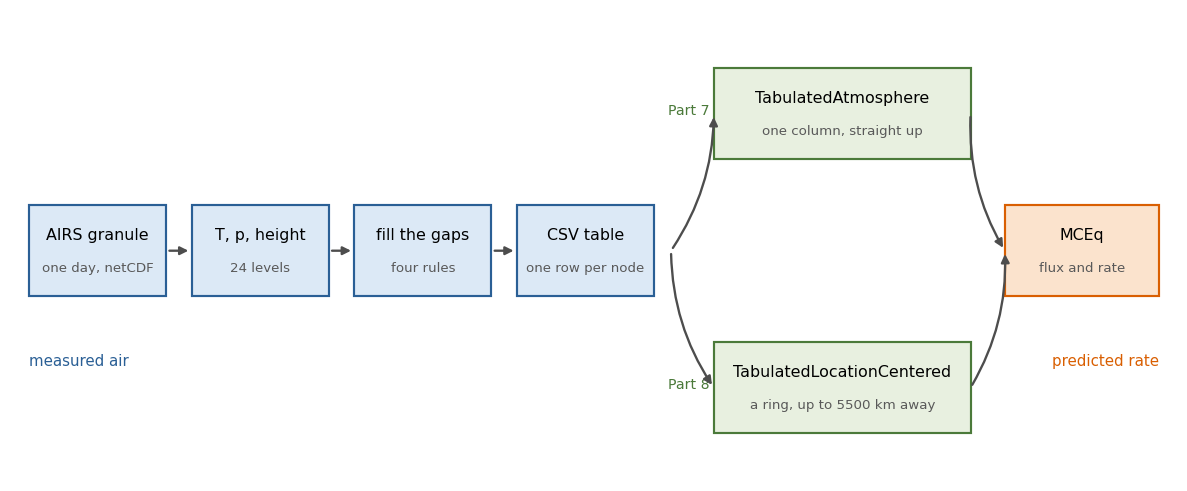

In [2]:
from matplotlib.patches import Rectangle

chain = [("AIRS granule", "one day, netCDF"), ("T, p, height", "24 levels"),
         ("fill the gaps", "four rules"), ("CSV table", "one row per node")]
fork = [("TabulatedAtmosphere", "one column, straight up", "Part 7"),
        ("TabulatedLocationCentered", "a ring, up to 5500 km away", "Part 8")]

fig, ax = plt.subplots(figsize=(10, 4.2), dpi=120)


def box(x, y, w, title, detail, fc, ec):
    ax.add_patch(Rectangle((x, y), w, 0.16, fc=fc, ec=ec, lw=1.3))
    ax.text(x + w / 2, y + 0.10, title, ha="center", fontsize=9.5)
    ax.text(x + w / 2, y + 0.045, detail, ha="center", fontsize=8, color="0.35")


for i, (title, detail) in enumerate(chain):
    box(i * 0.19, 0.42, 0.16, title, detail, "#dce9f6", "#2a5f95")
    if i:
        ax.annotate("", xy=(i * 0.19, 0.50), xytext=(i * 0.19 - 0.03, 0.50),
                    arrowprops=dict(arrowstyle="-|>", color="0.3", lw=1.4))

# After the table the notebook forks: the direction decides which class you use.
for k, (title, detail, part) in enumerate(fork):
    y = 0.66 if k == 0 else 0.18
    box(0.80, y, 0.30, title, detail, "#e8f0e0", "#4b7a3a")
    ax.text(0.795, y + 0.08, part, ha="right", fontsize=8.5, color="#4b7a3a")
    ax.annotate("", xy=(0.80, y + 0.08), xytext=(0.75, 0.50),
                arrowprops=dict(arrowstyle="-|>", color="0.3", lw=1.4,
                                connectionstyle="arc3,rad=0.15"))
    ax.annotate("", xy=(1.14, 0.50), xytext=(1.10, y + 0.08),
                arrowprops=dict(arrowstyle="-|>", color="0.3", lw=1.4,
                                connectionstyle="arc3,rad=0.15"))

box(1.14, 0.42, 0.18, "MCEq", "flux and rate", "#fbe3cd", "#d95f02")
ax.text(0.0, 0.30, "measured air", fontsize=9, color="#2a5f95")
ax.text(1.32, 0.30, "predicted rate", fontsize=9, color="#d95f02", ha="right")
ax.set_xlim(-0.02, 1.34), ax.set_ylim(0.10, 0.92)
ax.axis("off")
fig.tight_layout()

## 1. What AIRS is

AIRS is an infrared sounder on NASA's Aqua satellite, flying since 2002. It
measures the Earth's own infrared spectrum, and a retrieval turns that into a
temperature profile.

We use the daily gridded product, `AIRS3STD` v7.0: temperature and geopotential
height on 24 pressure levels from 1000 to 1 hPa, on a 1°×1° grid. Temperature
and pressure give density through the ideal gas law, and geopotential height
says at what altitude to put it. That is everything MCEq needs.

Aqua is in a polar orbit inclined 98.2°, so its ground track turns around at
81.8° and never crosses the pole. The polar cap is reached only by the edge of
the swath. The map below shows the consequence: right where IceCube sits, AIRS
looks least often.

The satellite crosses the equator twice a day, northbound at about 13:30 local
time and southbound at about 01:30. The product keeps the two passes as
separate grids, labelled A and D.

## 2. Getting the data

One AIRS granule is a 734 MB file holding about ninety fields. We need six.
OPeNDAP lets the server do the cutting: name the variables and the index
ranges, and it returns a small netCDF file. That is about 3 MB per day instead
of 734.

File names carry a production stamp that cannot be derived from the date, so
NASA's CMR catalogue is queried for them first. That also keeps the cache
honest, because a reprocessed day gets a new name and re-downloads by itself.

Credentials are read from `$EARTHDATA_TOKEN`, then `~/.edl_token`, then
`~/.netrc`. A token belongs in the first two; `~/.netrc` wants a username and
password.

In [3]:
# Boilerplate first: logging in, and downloading a subset.  Skim it.  The one
# part worth reading is the constraint string at the bottom.
CMR = "https://cmr.earthdata.nasa.gov/search/granules.json"
OPENDAP = "https://acdisc.gesdisc.eosdis.nasa.gov/opendap/Aqua_AIRS_Level3/AIRS3STD.7.0"


class EarthdataSession(requests.Session):
    """Keeps the Authorization header across the Earthdata Login redirect."""

    def rebuild_auth(self, request, response):
        # requests drops the header when a redirect changes host.  Right
        # everywhere else, wrong here, because the login lives on another host.
        if "Authorization" in request.headers:
            hosts = {urllib.parse.urlparse(u).hostname
                     for u in (response.request.url, request.url)}
            if len(hosts) > 1 and "urs.earthdata.nasa.gov" not in hosts:
                del request.headers["Authorization"]


def login():
    """A session authenticated by bearer token, or by ~/.netrc."""
    session = EarthdataSession()
    token = os.environ.get("EARTHDATA_TOKEN", "").strip()
    if not token and os.path.exists(os.path.expanduser("~/.edl_token")):
        token = open(os.path.expanduser("~/.edl_token")).read().strip()
    if token:
        session.headers["Authorization"] = f"Bearer {token}"
        return session
    try:
        user, _, password = netrc.netrc().authenticators("urs.earthdata.nasa.gov")
    except (FileNotFoundError, TypeError):
        raise RuntimeError(
            "No Earthdata credentials: set $EARTHDATA_TOKEN, write ~/.edl_token, "
            "or add urs.earthdata.nasa.gov to ~/.netrc."
        )
    session.auth = (user, password)
    return session


def find_granules(start, end):
    """{date: OPeNDAP url} for the AIRS3STD granules covering the dates."""
    reply = requests.get(CMR, timeout=60, params={
        "short_name": "AIRS3STD", "version": "7.0", "page_size": 200,
        "temporal": f"{start}T00:00:00Z,{end}T23:59:59Z"}).json()
    out = {}
    for entry in reply["feed"]["entry"]:
        name = entry["title"].split(":")[-1]      # ...AIRS.2013.08.05.L3....hdf
        year, month, day = name.split(".")[1:4]
        date = f"{year}-{month}-{day}"
        if start <= date <= end:
            out[date] = f"{OPENDAP}/{year}/{name}"
    return dict(sorted(out.items()))


def fetch(session, url, constraint):
    """Download one server-side subset, cached on the constraint's hash."""
    os.makedirs(CACHE_DIR, exist_ok=True)
    tag = hashlib.sha1(constraint.encode()).hexdigest()[:8]
    path = os.path.join(CACHE_DIR, url.rsplit("/", 1)[-1].replace(".hdf", f".{tag}.nc4"))
    if not os.path.exists(path):
        reply = session.get(f"{url}.nc4?{urllib.parse.quote(constraint, safe='[]:,.')}",
                            timeout=900)
        reply.raise_for_status()
        with open(path + ".part", "wb") as out:      # never leave a half file
            out.write(reply.content)
        os.replace(path + ".part", path)
    return path


session = login()
granules = find_granules(START_DATE, END_DATE)

# The axes are the same every day, so read them once and use them to find the
# index range of the latitude crop.
axes_path = fetch(session, next(iter(granules.values())),
                  "Latitude,Longitude,StdPressureLev")
with xr.open_dataset(axes_path) as axes:
    native_lat = axes["Latitude"].values.astype(float)
    n_lon = axes["Longitude"].size
    p_hpa_native = axes["StdPressureLev"].values.astype(float)

rows = np.flatnonzero((native_lat >= LAT_RANGE[0]) & (native_lat <= LAT_RANGE[1]))
J0, J1 = int(rows.min()), int(rows.max())

# Seven fields out of ninety: temperature and height for both passes, the
# terrain, and how many footprints landed in each cell.
FIELDS = [f"{name}_{pas}" for pas in OVERPASSES for name in ("Temperature", "GPHeight")]
SURFACE = ["Topography", "TotalCounts_A", "TotalCounts_D"]
constraint = ",".join(
    [f"{n}[0:{p_hpa_native.size - 1}][{J0}:{J1}][0:{n_lon - 1}]" for n in FIELDS]
    + [f"{n}[{J0}:{J1}][0:{n_lon - 1}]" for n in SURFACE]
    + [f"Latitude[{J0}:{J1}]", f"Longitude[0:{n_lon - 1}]",
       f"StdPressureLev[0:{p_hpa_native.size - 1}]"])

print("one variable's share of the constraint looks like this:")
print("   ", constraint.split(",")[0])

paths = {date: fetch(session, url, constraint) for date, url in granules.items()}
total = sum(os.path.getsize(p) for p in paths.values())
print(f"{len(paths)} granules, {total / 1e6:.0f} MB "
      f"(a whole granule is 734 MB, so this is {734 * len(paths) / (total / 1e6):.0f}x less)")

one variable's share of the constraint looks like this:
    Temperature_A[0:23][125:179][0:359]
7 granules, 20 MB (a whole granule is 734 MB, so this is 253x less)


In [4]:
def load_day(path):
    """One granule on ascending-latitude, [0,360) longitude axes."""
    with xr.open_dataset(path) as ds:
        lat = ds["Latitude"].values.astype(float)
        lon = ds["Longitude"].values.astype(float) % 360.0
        fields = {n: np.moveaxis(ds[n].values.astype(float), 0, -1)
                  for n in FIELDS}
        fields.update({n: ds[n].values.astype(float) for n in SURFACE})
    order_lat, order_lon = np.argsort(lat), np.argsort(lon)
    for name, value in fields.items():
        value = value[np.ix_(order_lat, order_lon)]
        # -9999 is AIRS's fill value and not every field declares it.
        fields[name] = np.where(value <= -9998.0, np.nan, value)
    return lat[order_lat], lon[order_lon], fields


# Levels ascending in height, i.e. descending in pressure.
level_order = np.argsort(p_hpa_native)[::-1]
p_hpa = p_hpa_native[level_order]

lat, lon, first = load_day(paths[START_DATE])
elevation_m = np.nan_to_num(first["Topography"], nan=0.0)
mapped = lat <= MAP_LAT_MAX

print(f"{lat.size} x {lon.size} columns, {p_hpa.size} levels "
      f"({p_hpa[0]:g} to {p_hpa[-1]:g} hPa)")
print(f"elevation {elevation_m.min():.0f} to {elevation_m.max():.0f} m, "
      f"{elevation_m[0].mean():.0f} m on the southernmost row (AIRS's own "
      f"value; SITE_ELEVATION_M is the surveyed one)")

55 x 360 columns, 24 levels (1000 to 1 hPa)
elevation 0 to 4033 m, 2816 m on the southernmost row (AIRS's own value; SITE_ELEVATION_M is the surveyed one)


85-90 S: 0.5 footprints per cell, 10% of it never looked at
the D pass looks the same; the two differ by hours, not by geometry


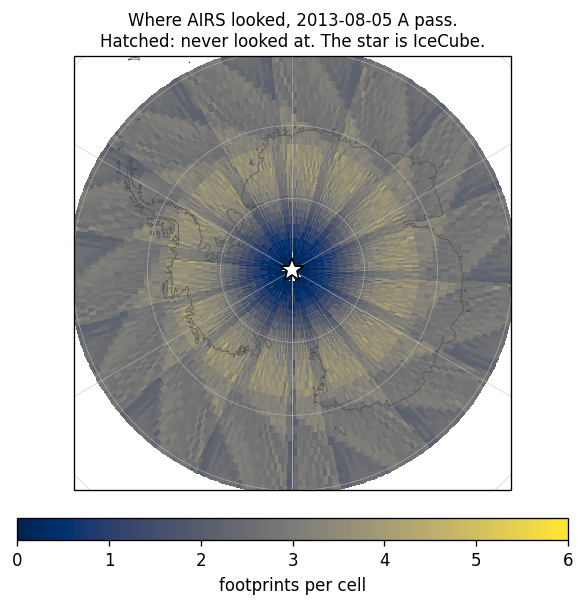

In [5]:
import cartopy.crs as ccrs

polar = ccrs.SouthPolarStereo()


def polar_map(ax, field, lat, lon, cmap, label, **kwargs):
    """A lon/lat field on a south polar stereographic map."""
    keep = lat <= MAP_LAT_MAX                       # the table reaches further
    lon_closed = np.append(lon, lon[0] + 360.0)     # close the 0/360 seam
    field_closed = np.concatenate([field[keep], field[keep][:, :1]], axis=1)
    mesh = ax.pcolormesh(lon_closed, lat[keep], field_closed, cmap=cmap,
                         shading="auto", transform=ccrs.PlateCarree(), **kwargs)
    ax.coastlines(lw=0.4, color="0.3")
    ax.gridlines(lw=0.3, color="0.75")
    ax.set_extent([-180, 180, -90, MAP_LAT_MAX], ccrs.PlateCarree())
    plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.9,
                 aspect=25, label=label)
    return mesh


never = first["TotalCounts_A"] == 0

fig = plt.figure(figsize=(5.4, 5.2), dpi=120)
ax = fig.add_subplot(projection=polar)
polar_map(ax, np.where(never, np.nan, first["TotalCounts_A"]), lat, lon,
          "cividis", "footprints per cell", vmin=0, vmax=6)
# Hatched, not a second colour scale: it is a flag, not a quantity.
blank = np.where(never[mapped], 0.0, np.nan)
ax.contourf(np.append(lon, lon[0] + 360.0), lat[mapped],
            np.concatenate([blank, blank[:, :1]], axis=1), levels=[-1, 1],
            colors="none", hatches=["////"], transform=ccrs.PlateCarree())
ax.plot(SITE_LON, SITE_LAT, "w*", ms=15, mec="k", transform=ccrs.PlateCarree())
ax.set_title(f"Where AIRS looked, {START_DATE} A pass.\nHatched: never looked "
             "at. The star is IceCube.", fontsize=10)
fig.tight_layout()

cap = first["TotalCounts_A"][lat <= -85.0]
print(f"85-90 S: {np.nanmean(cap):.1f} footprints per cell, "
      f"{np.mean(cap == 0):.0%} of it never looked at")
print("the D pass looks the same; the two differ by hours, not by geometry")

## 3. The gaps

AIRS is a measurement, not a model, so it reports a level only where the
retrieval worked. Cloud blocks it, and levels below the terrain do not exist.
MCEq needs every column to carry all 24 levels, so the holes have to be filled
before a table can be written at all.

Four rules do it, drawn below in order of how much each one invents. Rules 3
and 4 replace a whole column and are tagged, so the provenance map later is
honest about them. Rules 1 and 2 patch individual levels and are not: over the
plateau the lowest three or so levels of a column marked "measured" are rule-2
extrapolation. They sit below the ice surface and never enter the integration,
but they are there.

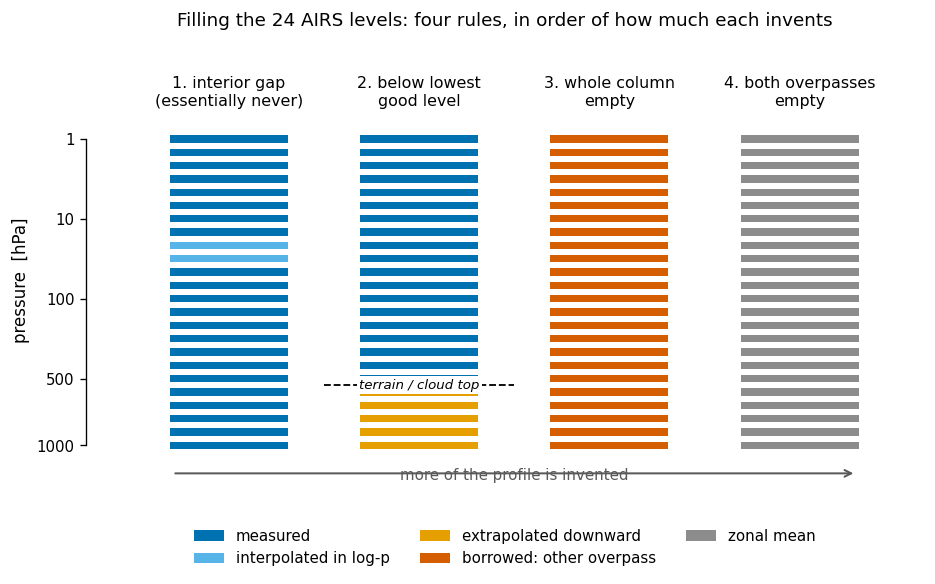

In [6]:
from matplotlib.patches import Patch

P = np.array([1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100,
              70, 50, 30, 20, 15, 10, 7, 5, 3, 2, 1.5, 1.0])   # 24 AIRS levels

# colour ramp: how much of the level is invented
COLOR = {"m": "#0072B2", "i": "#56B4E9", "x": "#E69F00", "b": "#D55E00", "z": "#8c8c8c"}
LABEL = {"m": "measured", "i": "interpolated in log-p", "x": "extrapolated downward",
         "b": "borrowed: other overpass", "z": "zonal mean"}

cols = [list("m" * 24), list("m" * 24), list("b" * 24), list("z" * 24)]
cols[0][14] = cols[0][15] = "i"       # 1: interior gap, good levels above and below
cols[1][0:5] = list("x" * 5)          # 2: nothing seen below the terrain / cloud
titles = ["1. interior gap\n(essentially never)", "2. below lowest\ngood level",
          "3. whole column\nempty", "4. both overpasses\nempty"]

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=120)
for k, col in enumerate(cols):
    for i, s in enumerate(col):
        ax.barh(i, 0.62, left=k - 0.31, height=0.55, color=COLOR[s])
    ax.text(k, 25.3, titles[k], ha="center", va="bottom", fontsize=9.5)

ax.plot([0.5, 1.5], [4.5, 4.5], "k--", lw=1.1)
ax.text(1.0, 4.5, "terrain / cloud top", fontsize=8, style="italic", ha="center",
        va="center", bbox=dict(fc="white", ec="none", pad=1.5))
ax.annotate("", xy=(3.3, -2.1), xytext=(-0.3, -2.1),
            arrowprops=dict(arrowstyle="->", color="0.35", lw=1.2))
ax.text(1.5, -2.6, "more of the profile is invented", fontsize=9, color="0.35", ha="center")

ax.set_yticks([0, 5, 11, 17, 23], [f"{p:g}" for p in P[[0, 5, 11, 17, 23]]], fontsize=9)
ax.set_ylabel("pressure  [hPa]", fontsize=10)
ax.set_xticks([])
ax.set_xlim(-0.75, 3.65)
ax.set_ylim(-3.2, 28.0)
ax.spines["left"].set_bounds(0, 23)
for side in ("top", "right", "bottom"):
    ax.spines[side].set_visible(False)
ax.set_title("Filling the 24 AIRS levels: four rules, in order of how much each invents",
             fontsize=11, pad=28)
ax.legend(handles=[Patch(fc=COLOR[s], label=LABEL[s]) for s in "mixbz"],
          loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False, fontsize=9)

In [7]:
MEASURED, OTHER_OVERPASS, ZONAL_MEAN = 0, 1, 2
SOURCE_NAMES = {MEASURED: "measured", OTHER_OVERPASS: "other overpass",
                ZONAL_MEAN: "zonal mean"}


def fill_gaps(t_k, gph_m, other):
    """Fill every column to all 24 levels. Returns (T, height, source)."""
    n_lat, n_lon, n_lev = t_k.shape
    t, gph = t_k.copy(), gph_m.copy()
    good = np.isfinite(t) & np.isfinite(gph)
    source = np.full((n_lat, n_lon), MEASURED, np.int8)

    # Rule 3 runs first, so that a borrowed column then gets rules 1 and 2
    # like any other.  The numbering is the figure's, not the order of work.
    # Rule 3: an empty column takes the other overpass of the same cell.
    empty = ~good.any(axis=-1)
    usable = np.isfinite(other[0]) & np.isfinite(other[1])
    rescued = empty & usable.any(axis=-1)
    t[rescued], gph[rescued] = other[0][rescued], other[1][rescued]
    source[rescued] = OTHER_OVERPASS
    good = np.isfinite(t) & np.isfinite(gph)

    x = -np.log(p_hpa)                       # increases with height
    for j, i in zip(*np.nonzero(good.any(axis=-1))):
        levels = np.flatnonzero(good[j, i])
        low, high = levels[0], levels[-1]

        # Rule 1: interior gaps, interpolated in log pressure.
        inside = ~good[j, i]
        inside[:low] = False              # below the lowest good level
        inside[high + 1:] = False         # above the highest
        if inside.any():
            t[j, i, inside] = np.interp(x[inside], x[levels], t[j, i, levels])
            gph[j, i, inside] = np.interp(x[inside], x[levels], gph[j, i, levels])

        # Rule 2: past either end, hold T and continue the height
        # hypsometrically.  Downward this is below the terrain or the cloud.
        for k in range(low - 1, -1, -1):
            t[j, i, k] = t[j, i, k + 1]
            gph[j, i, k] = gph[j, i, k + 1] - R_D / G0 * t[j, i, k] * np.log(
                p_hpa[k] / p_hpa[k + 1])
        for k in range(high + 1, n_lev):
            t[j, i, k] = t[j, i, k - 1]
            gph[j, i, k] = gph[j, i, k - 1] + R_D / G0 * t[j, i, k] * np.log(
                p_hpa[k - 1] / p_hpa[k])

    # Rule 4: still nothing usable in either pass -> the mean of the latitude
    # row.  "Usable" means T and height together: AIRS has columns with one
    # and not the other, and a temperature without an altitude is no profile.
    empty = ~good.any(axis=-1)
    for j in np.flatnonzero(empty.any(axis=-1)):
        assert (~empty[j]).any(), (
            f"latitude row {j} is empty in both passes, so there is nothing to "
            "average; widen LAT_RANGE or pick another day")
        t[j, empty[j]] = t[j, ~empty[j]].mean(axis=0)
        gph[j, empty[j]] = gph[j, ~empty[j]].mean(axis=0)
        source[j, empty[j]] = ZONAL_MEAN

    return t, gph, source

## 4. The table MCEq reads

The interface is a plain CSV. Nothing in it is specific to AIRS.

```
# MCEq tabulated atmosphere v1
lat_deg,lon_deg,h_cm,T_K,p_hPa
-89.0,0.0,283400.0,247.1,681.2
-89.0,0.0,510000.0,231.4,500.0
```

`h_cm` is height above sea level. Density comes from `T_K` and `p_hPa`. Adding
`lat_deg` and `lon_deg` turns one column into a grid of them, one row per node
and level.

One extra node is added at the pole, because AIRS's grid stops at −89° and
IceCube sits at −90°. At a pole every meridian meets, so its profile is the
mean of the −89° row over longitude. Part 8 cannot run without it.

In [8]:
def write_table(path, lat, lon, h_cm, t_k, p_hpa):
    """Write one gridded MCEq atmosphere table, one row per node and level."""
    n_lat, n_lon, n_lev = h_cm.shape
    rows = np.column_stack([
        np.repeat(lat, n_lon * n_lev), np.tile(np.repeat(lon, n_lev), n_lat),
        h_cm.reshape(-1), t_k.reshape(-1), np.tile(p_hpa, n_lat * n_lon)])
    with gzip.open(path, "wt", compresslevel=1) as out:
        out.write("# MCEq tabulated atmosphere v1\nlat_deg,lon_deg,h_cm,T_K,p_hPa\n")
        np.savetxt(out, rows, delimiter=",", fmt="%.4f,%.4f,%.6e,%.3f,%.6g")


def add_pole(lat, h_cm, t_k):
    """Add a node at -90: the mean of the southernmost row over longitude."""
    shape = (1,) + h_cm.shape[1:]
    return (np.concatenate([[-90.0], lat]),
            np.concatenate([np.broadcast_to(h_cm[0].mean(axis=0), shape), h_cm]),
            np.concatenate([np.broadcast_to(t_k[0].mean(axis=0), shape), t_k]))


os.makedirs(OUTPUT_DIR, exist_ok=True)
np.savetxt(SURFACE_TABLE, np.column_stack([
    np.repeat(lat, lon.size), np.tile(lon, lat.size), elevation_m.reshape(-1)]),
    delimiter=",", fmt="%.4f,%.4f,%.2f",
    header="lat_deg,lon_deg,h_surface_m", comments="")

table_files, column_source, map_temperature = {}, {}, {}
# About 16 km: above every terrain, and in the layer where the mesons behind
# 100 GeV neutrinos are made.
MAP_LEVEL = int(np.argmin(np.abs(p_hpa - 100.0)))

for date, path in paths.items():
    _, _, fields = load_day(path)
    raw = {p: (fields[f"Temperature_{p}"][..., level_order],
               fields[f"GPHeight_{p}"][..., level_order]) for p in OVERPASSES}
    for pas in OVERPASSES:
        other = raw["D" if pas == "A" else "A"]
        t_k, gph_m, source = fill_gaps(*raw[pas], other)
        assert 150 < np.nanmin(t_k) and np.nanmax(t_k) < 350, "T is not in kelvin"
        broken = np.argwhere(~(np.diff(gph_m, axis=-1) > 0))
        assert not len(broken), (
            f"{date} {pas}: heights not increasing, first at lat "
            f"{lat[broken[0][0]]}, lon {lon[broken[0][1]]}, level {broken[0][2]}")

        # The region and the filling rules are in the name, so a re-run with
        # different settings writes new files instead of reusing old ones.
        tag = hashlib.sha1(f"{LAT_RANGE}{FILL_VERSION}".encode()).hexdigest()[:6]
        out_path = os.path.join(OUTPUT_DIR, f"airs_{date}_{pas}_{tag}.csv.gz")
        if not os.path.exists(out_path):
            pole_lat, h_cm, pole_t = add_pole(lat, gph_m * 100.0, t_k)
            write_table(out_path, pole_lat, lon, h_cm, pole_t, p_hpa)
        table_files[(date, pas)] = out_path
        column_source[(date, pas)] = source
        map_temperature[(date, pas)] = t_k[..., MAP_LEVEL]
    print(f"{date} A pass  " + "  ".join(
        f"{name} {np.mean(column_source[(date, 'A')] == value):.0%}"
        for value, name in SOURCE_NAMES.items()))

2013-08-05 A pass  measured 85%  other overpass 11%  zonal mean 4%
2013-08-06 A pass  measured 87%  other overpass 9%  zonal mean 4%


2013-08-07 A pass  measured 87%  other overpass 10%  zonal mean 3%
2013-08-08 A pass  measured 88%  other overpass 9%  zonal mean 3%


2013-08-09 A pass  measured 87%  other overpass 9%  zonal mean 3%
2013-08-10 A pass  measured 88%  other overpass 9%  zonal mean 3%


2013-08-11 A pass  measured 87%  other overpass 9%  zonal mean 4%


## 5. Driving MCEq with the table

```python
table = dp.AtmosphereTable.load_from_csv("airs_2013-08-05_A.csv.gz")
atm = dp.TabulatedAtmosphere(table, coord=(lon, lat), surface_elevation_m=2835)
atm.set_theta(0.0)
atm.max_X          # vertical column depth, g/cm^2
```

Three arguments matter. `coord` picks the column. `surface_elevation_m` is
where the ground is, which sets the bottom of the calculation.
`top_extension` says how to continue the profile above 1 hPa, and defaults to
an isothermal tail.

One thing to know: a `TabulatedAtmosphere` uses the same column for every
direction. Straight up that is exact. At large zenith angles the shower drifts
hundreds of kilometres downrange, and then you want
`TabulatedLocationCentered`, which is what Part 8 uses.

The figure compares one AIRS column at the pole against NRLMSISE-00, the
climatology MCEq ships with.

AtmosphereTable(grid 56x360, 24 levels, lat -90.00..-35.00, lon 0.00..359.00)


vertical column depth: AIRS 687, NRLMSISE-00 698 g/cm^2 (-1.5%)


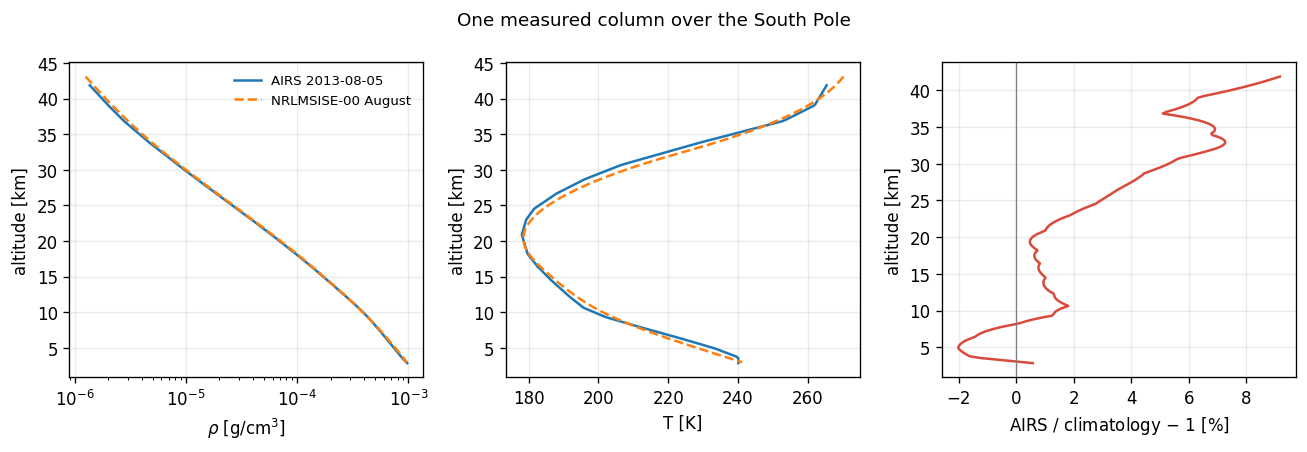

In [9]:
import MCEq.geometry.density_profiles as dp

first_key = (START_DATE, "A")
table = dp.AtmosphereTable.load_from_csv(table_files[first_key])
print(table)

airs_atm = dp.TabulatedAtmosphere(table, coord=(SITE_LON, SITE_LAT),
                                  surface_elevation_m=SITE_ELEVATION_M)
msis_atm = dp.MSIS00IceCubeCentered("SouthPole", SEASON)
for atm in (airs_atm, msis_atm):
    atm.set_theta(0.0)

print(f"vertical column depth: AIRS {airs_atm.max_X:.0f}, "
      f"NRLMSISE-00 {msis_atm.max_X:.0f} g/cm^2 "
      f"({100 * (airs_atm.max_X / msis_atm.max_X - 1):+.1f}%)")

# Read the profiles back through the interface MCEq integrates, not from file.
X = np.geomspace(1.0, min(airs_atm.max_X, msis_atm.max_X), 200)
height = {a: np.array([a.X2h(x) for x in X]) / 1e5 for a in (airs_atm, msis_atm)}
density = {a: np.array([a.X2rho(x) for x in X]) for a in (airs_atm, msis_atm)}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), dpi=120)
for atm, label, style in ((airs_atm, f"AIRS {START_DATE}", "-"),
                          (msis_atm, f"NRLMSISE-00 {SEASON}", "--")):
    axes[0].plot(density[atm], height[atm], style, label=label)
    axes[1].plot([atm.get_temperature(h * 1e5) for h in height[atm]],
                 height[atm], style, label=label)
axes[2].plot(100 * (density[airs_atm] / density[msis_atm] - 1), height[airs_atm],
             color="#d94a3d")
axes[2].axvline(0, color="0.5", lw=0.8)

axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\rho$ [g/cm$^3$]")
axes[1].set_xlabel("T [K]")
axes[2].set_xlabel("AIRS / climatology $-$ 1 [%]")
for ax in axes:
    ax.set_ylabel("altitude [km]")
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle("One measured column over the South Pole", fontsize=11)
fig.tight_layout()

## 6. From atmosphere to flux to rate

```python
mceq = MCEqRun(interaction_model="SIBYLL2.3d", primary_model=(pm.HillasGaisser2012, "H3a"),
               theta_deg=0.0, density_model=atm)
mceq.solve()
mceq.get_solution("total_numu")                       # dN/dE per cm2 s sr GeV
mceq.n_particles("total_numu", min_energy_cutoff=100) # integrated, per cm2 s sr
```

`get_solution` returns a differential flux. `n_particles` integrates it above a
threshold, and that is what this notebook calls the rate. Despite the name it
is still per steradian, and still not an event rate.

`total_numu` is the neutrino only. The antineutrino is a separate particle,
`total_antinumu`, and the two are always added below. The cell prints the
ratio, because leaving it out is a large error in a plausible direction.

The threshold matters more than it looks. The spectrum is steep, so about 90%
of a rate above 100 GeV is carried by neutrinos below 300 GeV: the threshold is
very nearly the energy you are studying.

Where you put it decides how much the atmosphere can matter. The critical
energies — where a meson is as likely to interact as to decay — are 115 GeV for
pions and 850 GeV for kaons. Those are **meson** energies, and a neutrino
carries only part of its parent: about a fifth of a pion, about half a kaon. In
neutrino energy the two transitions therefore sit near 30 GeV and 500 GeV, and
that is where they are drawn below.

So a 100 GeV neutrino comes from a roughly 500 GeV pion, already well above
ε_π: the air matters here. The third panel shows the effect still growing past
it, so a TeV threshold would show a larger one.

MCEqRun::set_interaction_model(): SIBYLL23D
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, np.int64(0))).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, np.int64(0))).


MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)


threshold 100 GeV snaps to the bin edge at 100 GeV


rate() against MCEq's own n_particles: 1.493484e-06 vs 1.493484e-06
rate above 100 GeV: AIRS 1.493e-06, climatology 1.501e-06 /cm^2/s/sr (-0.47%)


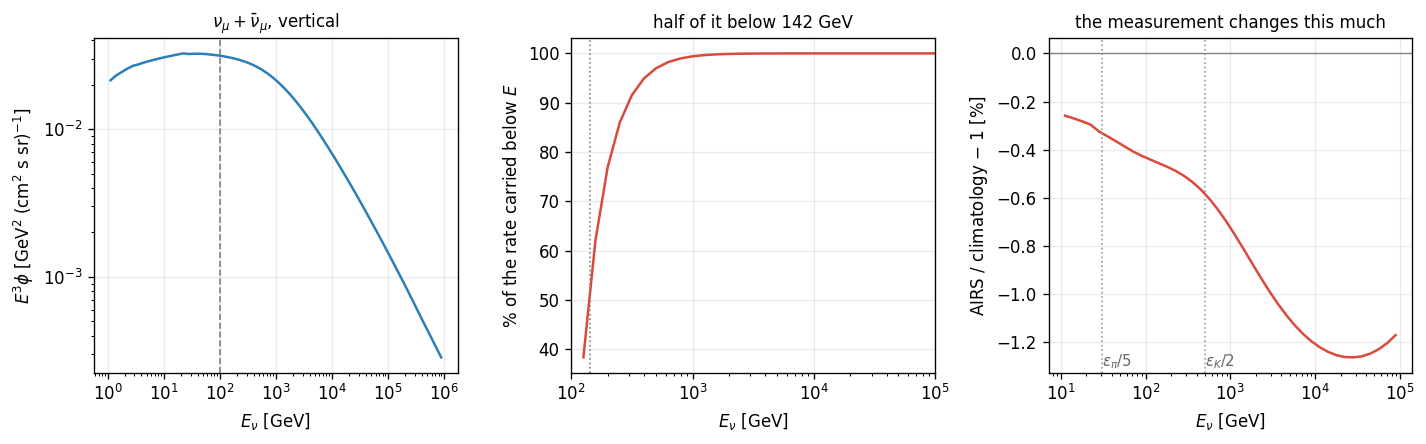

In [10]:
import crflux.models as pm

import MCEq.config as config

# Nothing here needs neutrinos above 1e8 GeV, and cutting the grid there drops
# a quarter of the states.  config is read when MCEqRun is built, so set it
# first.  The top decade of the grid is not trustworthy after the cut, so no
# plot below goes past 1e6 GeV.  (The rate integral formally runs to the top of
# the grid, but everything above 1e6 GeV contributes about 1e-10 of it.)
config.e_max = 1.0e8

from MCEq.core import MCEqRun

NU = ("total_numu", "total_antinumu")     # a detector counts both

mceq = MCEqRun(interaction_model="SIBYLL2.3d",
               primary_model=(pm.HillasGaisser2012, "H3a"),
               theta_deg=0.0, density_model=airs_atm)
e_grid, e_bins, e_widths = mceq.e_grid, mceq.e_bins, mceq.e_widths
edge = float(e_bins[e_bins >= E_THRESHOLD][0])


# e_bins are edges, e_widths and e_grid are the bins between them, so the same
# index selects the bin that starts at `edge`.
first_bin = int(np.searchsorted(e_bins, E_THRESHOLD))


def rate(spectra):
    """Flux integrated above E_THRESHOLD, per cm^2 s sr. Works on arrays."""
    return np.sum((np.asarray(spectra) * e_widths)[..., first_bin:], axis=-1)


# Two atmospheres, one batched call: this is how every grid below is solved.
solved = mceq.solve_batch(conditions=[{"zenith_deg": 0.0, "density_model": a}
                                      for a in (airs_atm, msis_atm)])
airs_flux, msis_flux = (sum(solved.get_solution(n, k=k) for n in NU)
                        for k in (0, 1))

# rate() is MCEqRun.n_particles, vectorised so it works on a whole map at once.
print(f"threshold {E_THRESHOLD:.0f} GeV snaps to the bin edge at {edge:.0f} GeV")
mceq.set_density_model(airs_atm)
mceq.set_zenith_azimuth(0.0)
mceq.solve()
print("rate() against MCEq's own n_particles: "
      f"{rate(sum(mceq.get_solution(n) for n in NU)):.6e} vs "
      f"{sum(mceq.n_particles(n, min_energy_cutoff=E_THRESHOLD) for n in NU):.6e}")
print(f"rate above {edge:.0f} GeV: AIRS {rate(airs_flux):.3e}, "
      f"climatology {rate(msis_flux):.3e} /cm^2/s/sr "
      f"({100 * (rate(airs_flux) / rate(msis_flux) - 1):+.2f}%)")

# Where does that rate come from, and how much does the atmosphere change it?
above = (airs_flux * e_widths)[first_bin:]
fraction = np.cumsum(above) / above.sum()      # fraction below each bin's top
half = np.interp(0.5, fraction, e_bins[first_bin + 1:])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), dpi=120)
shown = (e_grid >= 1.0) & (e_grid <= 1.0e6)
axes[0].loglog(e_grid[shown], (airs_flux * e_grid**3)[shown], color="#2c7fb8")
axes[0].axvline(edge, color="0.5", ls="--", lw=1)
axes[0].set_ylabel(r"$E^3\phi$ [GeV$^2$ (cm$^2$ s sr)$^{-1}$]")
axes[0].set_title(r"$\nu_\mu + \bar\nu_\mu$, vertical", fontsize=10)

axes[1].semilogx(e_bins[first_bin + 1:], 100 * fraction, color="#d94a3d")
axes[1].axvline(half, color="0.5", ls=":", lw=1)
axes[1].set_xlim(edge, 1e5)
axes[1].set_ylabel(f"% of the rate carried below $E$")
axes[1].set_title(f"half of it below {half:.0f} GeV", fontsize=10)

band = (e_grid >= 10.0) & (e_grid <= 1.0e5)
axes[2].semilogx(e_grid[band], 100 * (airs_flux / msis_flux - 1)[band],
                 color="#d94a3d")
axes[2].axhline(0, color="0.5", lw=0.8)
# The critical energies are the MESON's.  A neutrino takes about a fifth of a
# pion and about half a kaon, so on this axis the breaks sit far lower.
for energy, name in ((31.0, r"$\epsilon_\pi/5$"), (500.0, r"$\epsilon_K/2$")):
    axes[2].axvline(energy, color="0.6", ls=":", lw=1)
    axes[2].annotate(name, (energy, 0.02), xycoords=("data", "axes fraction"),
                     fontsize=9, color="0.4")
axes[2].set_ylabel("AIRS / climatology $-$ 1 [%]")
axes[2].set_title("the measurement changes this much", fontsize=10)

for ax in axes:
    ax.set_xlabel(r"$E_\nu$ [GeV]")
    ax.grid(alpha=0.25)
fig.tight_layout()

## 7. The rate across Antarctica

One atmosphere per grid node, one solve per node, all of them in a single
`solve_batch` call. Each map cell is therefore a detector standing there,
looking straight up.

The rate is lowest over the plateau and rises towards the Southern Ocean. Two
things push that way at once: the polar vortex holds the coldest and densest
air over the pole, and the plateau is also 3 km high. The cell measures the
second separately so they are not confused.

The animation shows the seven days as departures from the weekly mean. The
motion is weather, not gap filling: the cell checks that by splitting the
spread between nodes that were measured every day and the rest.

240 columns in 9 s, 5.9% between the extreme nodes


of which the ground alone: -2.0% over the 4033 m the map spans,
so the middle panel is about a third of the left one and the air the rest


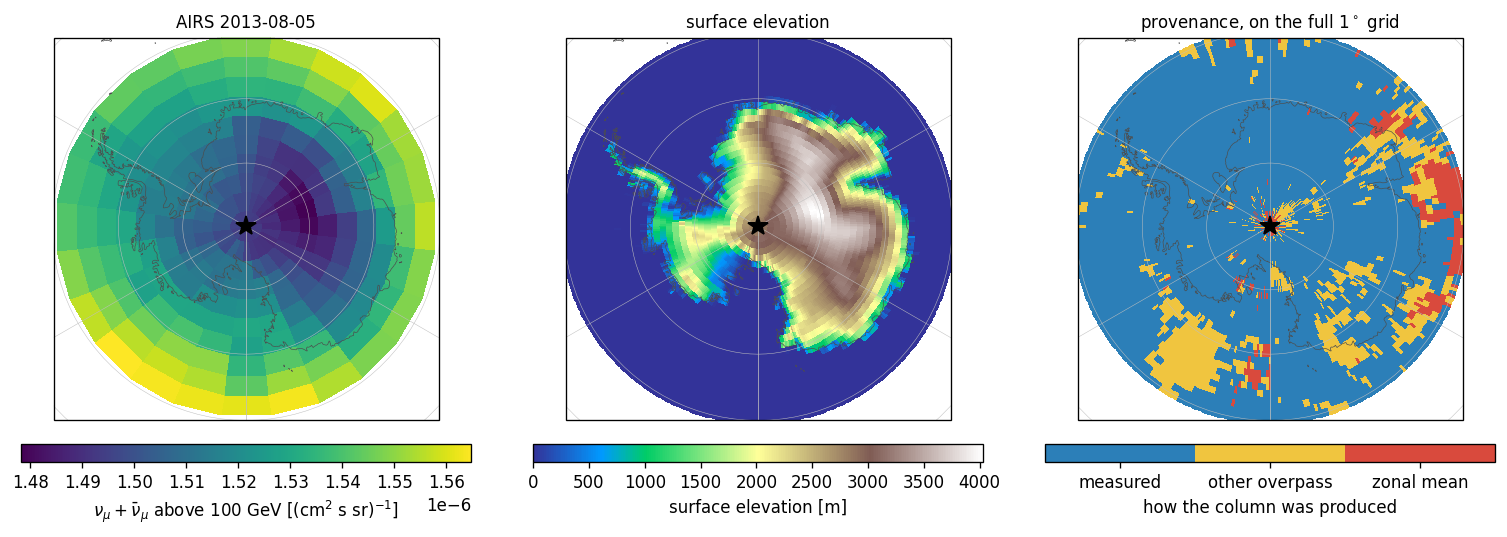

In [11]:
map_j = np.flatnonzero(mapped)[::LAT_STRIDE]
map_i = np.arange(lon.size)[::LON_STRIDE]
map_lat, map_lon = lat[map_j], lon[map_i]


def rate_map(table):
    """Vertical numu+antinumu spectra at every map node, in one batched solve."""
    atmospheres = [
        dp.TabulatedAtmosphere(table, coord=(float(lon[i]), float(lat[j])),
                               surface_elevation_m=max(elevation_m[j, i], 0.0))
        for j in map_j for i in map_i]
    solution = mceq.solve_batch(
        conditions=[{"zenith_deg": 0.0, "density_model": a} for a in atmospheres])
    spectra = np.array([sum(solution.get_solution(n, k=k) for n in NU)
                        for k in range(solution.K)])
    return spectra.reshape(map_lat.size, map_lon.size, e_grid.size)


start = time.time()
spectra = rate_map(table)
today = rate(spectra)
print(f"{today.size} columns in {time.time() - start:.0f} s, "
      f"{100 * (today.max() / today.min() - 1):.1f}% between the extreme nodes")

# How much of that spread is the ground rather than the air?  One column,
# moved across the same range of elevations the map covers.
ground = mceq.solve_batch(conditions=[
    {"zenith_deg": 0.0, "density_model":
     dp.TabulatedAtmosphere(table, coord=(SITE_LON, SITE_LAT),
                            surface_elevation_m=h)}
    for h in (0.0, elevation_m[mapped].max())])
low, high = (rate(sum(ground.get_solution(n, k=k) for n in NU)) for k in (0, 1))
print(f"of which the ground alone: {100 * (high / low - 1):+.1f}% over the "
      f"{elevation_m[mapped].max():.0f} m the map spans,")
print("so the middle panel is about a third of the left one and the air the rest")

fig = plt.figure(figsize=(13, 4.6), dpi=120)
ax = fig.add_subplot(1, 3, 1, projection=polar)
polar_map(ax, today, map_lat, map_lon, "viridis",
          rf"$\nu_\mu+\bar\nu_\mu$ above {edge:.0f} GeV [(cm$^2$ s sr)$^{{-1}}$]")
ax.set_title(f"AIRS {START_DATE}", fontsize=10)

ax = fig.add_subplot(1, 3, 2, projection=polar)
polar_map(ax, elevation_m, lat, lon, "terrain", "surface elevation [m]")
ax.set_title("surface elevation", fontsize=10)

ax = fig.add_subplot(1, 3, 3, projection=polar)
mesh = polar_map(ax, column_source[first_key].astype(float), lat, lon,
                 plt.matplotlib.colors.ListedColormap(
                     ["#2c7fb8", "#f0c53f", "#d94a3d"]),
                 "how the column was produced", vmin=-0.5, vmax=2.5)
mesh.colorbar.set_ticks(list(SOURCE_NAMES))
mesh.colorbar.set_ticklabels(list(SOURCE_NAMES.values()))
ax.set_title("provenance, on the full 1$^\\circ$ grid", fontsize=10)

for ax in fig.axes[::2]:
    ax.plot(SITE_LON, SITE_LAT, "k*", ms=12, transform=ccrs.PlateCarree())
fig.tight_layout()

In [12]:
from matplotlib import animation
from IPython.display import HTML

week_dates = sorted({d for d, pas in table_files})
day_tables = {START_DATE: table}
week = [spectra]

start = time.time()
for date in week_dates[1:]:
    day_tables[date] = dp.AtmosphereTable.load_from_csv(table_files[(date, "A")])
    week.append(rate_map(day_tables[date]))
    print(f"  {date}  {time.time() - start:4.0f} s")
week = np.array(week)

week_rate = rate(week)
anomaly = 100 * (week_rate / week_rate.mean(axis=0) - 1)
swing = 100 * (week_rate.max(axis=0) / week_rate.min(axis=0) - 1)

# Is the motion weather, or the gap filling changing its mind between days?
always = np.array([column_source[(d, "A")][np.ix_(map_j, map_i)] == MEASURED
                   for d in week_dates]).all(axis=0)
print(f"\nday to day: {np.median(swing):.2f}% at the median node")
print(f"  measured every day ({always.mean():.0%} of nodes): "
      f"{np.median(swing[always]):.2f}%,  the rest: {np.median(swing[~always]):.2f}%")

fig = plt.figure(figsize=(6, 6.4), dpi=110)
ax = fig.add_subplot(projection=polar)
limit = np.percentile(np.abs(anomaly), 99)
mesh = polar_map(ax, anomaly[0], map_lat, map_lon, "RdBu_r",
                 "departure from the weekly mean [%]", vmin=-limit, vmax=limit)
ax.plot(SITE_LON, SITE_LAT, "k*", ms=12, transform=ccrs.PlateCarree())
title = ax.set_title("")


def draw(step):
    closed = np.concatenate([anomaly[step], anomaly[step][:, :1]], axis=1)
    mesh.set_array(closed.ravel())
    title.set_text(week_dates[step])
    return mesh, title


ani = animation.FuncAnimation(fig, draw, frames=len(week_dates), interval=700)
plt.close(fig)
HTML(ani.to_jshtml())

  2013-08-06    10 s


  2013-08-07    20 s


  2013-08-08    31 s


  2013-08-09    42 s


  2013-08-10    54 s


  2013-08-11    65 s

day to day: 0.57% at the median node
  measured every day (46% of nodes): 0.54%,  the rest: 0.59%


## 8. What IceCube sees

IceCube's clean muon-neutrino sample comes from below. A muon travelling upward
cannot have been made in the sky overhead, because the Earth would have
stopped it, so the Earth itself is the veto. The real sample runs from the
horizon all the way to 180°; this notebook stops at 115° only because that is
as far as the downloaded region reaches.

The catch is in the schematic. A neutrino arriving from 115° entered the
atmosphere about 50° of great circle away, over the Southern Ocean. The air
that made it is nowhere near the detector, and is about 29 K warmer. Tilting
the pole's own column would be simply wrong.

The schematic also explains something the printed table below would otherwise
make look backwards: the column depth *falls* as the detector zenith grows.
Further below the horizon means the shower stands closer to its own vertical,
so it crosses less air, not more.

`TabulatedLocationCentered` samples the table where the shower actually is.
Without an azimuth it averages around the ring of impact points, which at the
pole is a circle of constant latitude. This is also why the download reaches to
35°S rather than stopping at the coast.

Above 1 hPa the profile is continued with NRLMSIS 2.1 rather than an
isothermal tail. Not because the path is tangential — at 115° the shower
actually stands most upright — but because its whole slant column is only about
2400 g/cm², so the unmeasured part above the table is a much larger share of
where the shower develops. The cell measures what the choice is worth, and it
is not small. Straight up it is negligible, which is why Parts 5 to 7 keep the
default.

Two features of the zenith scan below are worth not glossing over. The column
depth turns over between 90° and 92.5°, because right at the horizon the path
is still referenced to the detector's own surface rather than to the far side.
And the AIRS-minus-climatology curve is not flat: it dips near 102–105°, where
the impact ring sits at 60–65°S. That is both where the vortex edge lies and
where Part 3's gap filling is heaviest. This notebook does not separate the
two, and you should not assume which it is.

(None,
 (np.float64(-1.63), np.float64(-0.3), np.float64(-0.3), np.float64(1.25)))

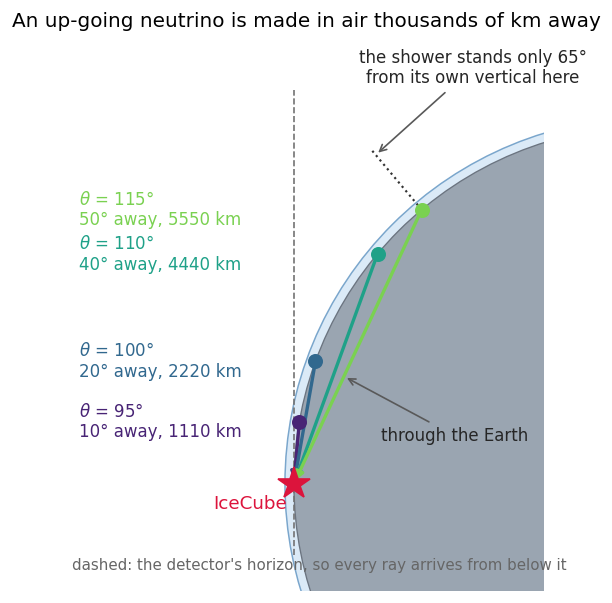

In [13]:
# Zoomed on the sector that matters.  The atmosphere shell is drawn thicker
# than it is; the entry points are placed on the surface, 2*theta - 180 degrees
# of great circle from the detector, which makes each drawn ray arrive at
# exactly its labelled zenith.
R, H = 1.0, 0.025
detector = np.array([-R, 0.0])

fig, ax = plt.subplots(figsize=(7.4, 6.0), dpi=120)
ax.add_patch(plt.Circle((0, 0), R + H, fc="#dbeaf7", ec="#7aa6cc", lw=0.9))
ax.add_patch(plt.Circle((0, 0), R, fc="#9aa5b1", ec="#6b7480", lw=0.8))
ax.plot([-R, -R], [-0.2, 1.1], "--", color="0.45", lw=1)

for theta, colour in zip([95, 100, 110, 115],
                         plt.cm.viridis(np.linspace(0.1, 0.8, 4))):
    away = 2 * theta - 180                      # degrees of great circle
    out = np.array([-np.cos(np.radians(away)), np.sin(np.radians(away))])
    ax.annotate("", xy=detector, xytext=R * out,
                arrowprops=dict(arrowstyle="-|>", color=colour, lw=2.0))
    ax.plot(*(R * out), "o", color=colour, ms=8, zorder=4)
    ax.text(-1.60, R * out[1], f"$\\theta$ = {theta}°\n{away}° away, "
            f"{away * 111:.0f} km", color=colour, fontsize=10, va="center")

# At the far end the shower stands much closer to its own vertical.
far = R * np.array([-np.cos(np.radians(50)), np.sin(np.radians(50))])
ax.plot(*np.c_[far, 1.22 * far], ":", color="0.2", lw=1.3)
ax.annotate("the shower stands only 65°\nfrom its own vertical here",
            xy=1.20 * far, xytext=(-0.50, 1.12), fontsize=10, color="0.15",
            ha="center", arrowprops=dict(arrowstyle="->", color="0.35"))
ax.annotate("through the Earth", xy=(-0.86, 0.30), xytext=(-0.55, 0.12),
            fontsize=10, color="0.15", ha="center",
            arrowprops=dict(arrowstyle="->", color="0.35"))

ax.plot(*detector, "*", color="crimson", ms=20, zorder=5)
ax.text(-R - 0.02, -0.07, "IceCube", ha="right", fontsize=11, color="crimson")
ax.text(-1.62, -0.24, "dashed: the detector's horizon, so every ray arrives "
        "from below it", fontsize=9, color="0.4")
ax.set_title("An up-going neutrino is made in air thousands of km away",
             fontsize=12)
ax.set_xlim(-1.63, -0.30), ax.set_ylim(-0.30, 1.25)
ax.set_aspect("equal"), ax.axis("off")

In [14]:
import datetime


def detector_atmosphere(table, date, extension="msis21"):
    """The atmosphere IceCube sees, sampled where the shower actually is."""
    return dp.TabulatedLocationCentered(
        table,
        detector_coord=(SITE_LON, SITE_LAT),
        surface_elevation_m=SITE_ELEVATION_M,   # ice surface above sea level
        depth_m=SITE_DEPTH_M,                   # detector below that surface
        n_azimuth=36,                           # samples for the ring average
        max_theta=180.0,                        # needed to accept zenith > 90
        top_extension=extension,                # NRLMSIS 2.1 above 1 hPa
        # doy dates the MSIS tail only.  The AIRS data is not touched by it.
        doy=datetime.date.fromisoformat(date).timetuple().tm_yday)


ic_atm = detector_atmosphere(table, START_DATE)

# Where is the shower?  Ask the geometry rather than trusting the formula.
print(f"{'zenith':>7s}{'impact lat':>12s}{'distance':>10s}{'column depth':>14s}")
impact_lat, depth = [], []
for zenith in ZENITH_BAND:
    ic_atm.set_theta(float(zenith), azimuth_deg=0.0)   # one azimuth: a point
    impact_lat.append(ic_atm.current_impact_latitude)
    ic_atm.set_theta(float(zenith))                    # the averaged ring
    depth.append(ic_atm.max_X)
    if zenith in ZENITH_BAND[::2]:               # print every second one
        print(f"{zenith:7.0f}{impact_lat[-1]:+12.1f}"
              f"{abs(impact_lat[-1] - SITE_LAT):7.0f} deg"
              f"{ic_atm.max_X:12.0f} g/cm^2")
impact_lat, depth = np.array(impact_lat), np.array(depth)

# What is the profile above the table worth?  Measure it: at 115 deg the whole
# slant column is small, so the unmeasured top is a big share of it.
tail = mceq.solve_batch(conditions=[
    {"zenith_deg": float(z), "density_model": atmosphere}
    for atmosphere in (ic_atm, detector_atmosphere(table, START_DATE, "isothermal"))
    for z in (ZENITH_BAND[0], ZENITH_BAND[-1])])
msis_rate, iso_rate = (rate(np.array([
    sum(tail.get_solution(n, k=k) for n in NU) for k in pair]))
    for pair in ((0, 1), (2, 3)))
for k, zenith in enumerate((ZENITH_BAND[0], ZENITH_BAND[-1])):
    print(f"swapping the MSIS tail for an isothermal one at {zenith:.0f} deg: "
          f"{100 * (iso_rate[k] / msis_rate[k] - 1):+.2f}%")

 zenith  impact lat  distance  column depth
     90       -88.6      1 deg       15909 g/cm^2
     95       -80.1     10 deg       10779 g/cm^2
    100       -70.0     20 deg        5654 g/cm^2
    105       -60.0     30 deg        3854 g/cm^2


    110       -50.0     40 deg        2975 g/cm^2
    115       -40.0     50 deg        2433 g/cm^2


swapping the MSIS tail for an isothermal one at 90 deg: +0.01%
swapping the MSIS tail for an isothermal one at 115 deg: +0.86%


the air at the far end of the band is 29 K warmer than the air over the detector


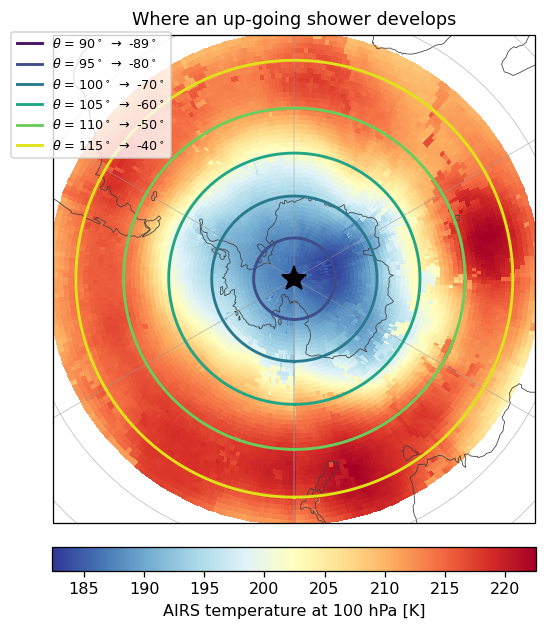

In [15]:
# The rings the azimuth average runs around, on the air they sample.
shown_T = map_temperature[first_key]

fig = plt.figure(figsize=(6.4, 6.8), dpi=115)
ax = fig.add_subplot(projection=polar)
ax.set_extent([-180, 180, -90, float(lat.max())], ccrs.PlateCarree())
mesh = ax.pcolormesh(np.append(lon, lon[0] + 360), lat,
                     np.concatenate([shown_T, shown_T[:, :1]], axis=1),
                     cmap="RdYlBu_r", shading="auto",
                     transform=ccrs.PlateCarree())
ax.coastlines(lw=0.5, color="0.25")
ax.gridlines(lw=0.3, color="0.6")
plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85,
             label=f"AIRS temperature at {p_hpa[MAP_LEVEL]:.0f} hPa [K]")

circle = np.linspace(-180, 180, 721)
shown = slice(None, None, 2)
for zenith, latitude, colour in zip(ZENITH_BAND[shown], impact_lat[shown],
                                    plt.cm.viridis(np.linspace(0.05, 0.95, 6))):
    ax.plot(circle, np.full_like(circle, latitude), color=colour, lw=1.8,
            transform=ccrs.Geodetic(),
            label=rf"$\theta$ = {zenith:.0f}$^\circ$ $\to$ {latitude:.0f}$^\circ$")
ax.plot(SITE_LON, SITE_LAT, "k*", ms=16, transform=ccrs.PlateCarree(), zorder=5)
ax.legend(loc="upper left", bbox_to_anchor=(-0.1, 1.02), fontsize=8)
ax.set_title("Where an up-going shower develops", fontsize=11)

near, far = (np.nanmean(shown_T[np.argmin(np.abs(lat - x))])
             for x in (impact_lat[0], impact_lat[-1]))
print(f"the air at the far end of the band is {far - near:.0f} K warmer "
      f"than the air over the detector")

AIRS         band-integrated 8.035e-06 /cm^2/s
climatology  band-integrated 8.117e-06 /cm^2/s
over 2.655 sr


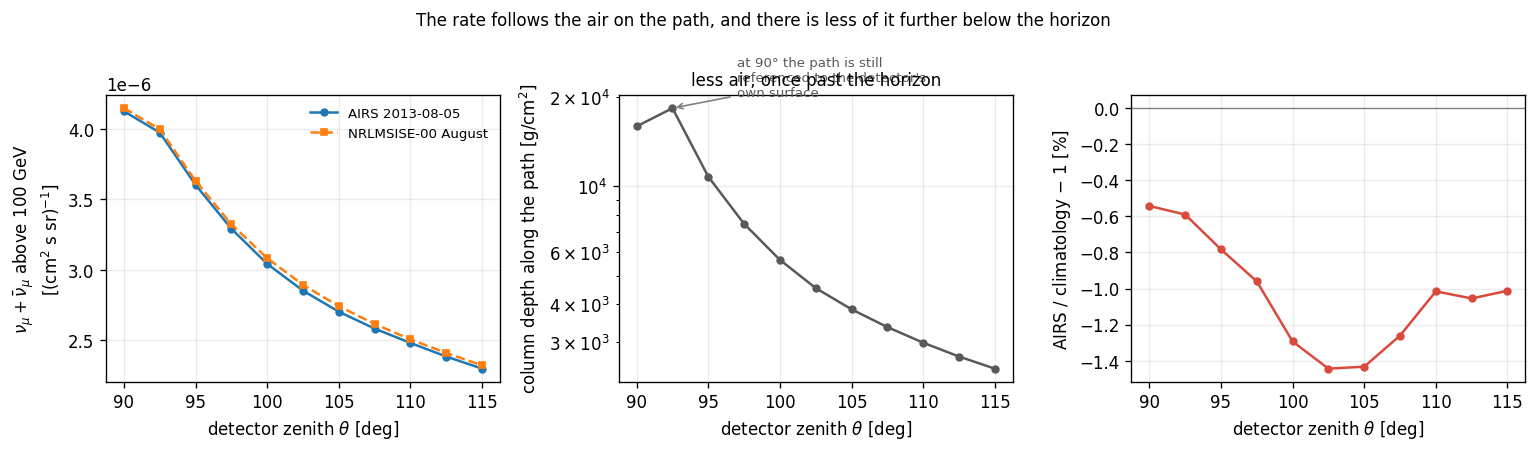

In [16]:
def integrate_band(theta_deg, flux_per_sr):
    """2*pi * int flux dcos(theta): per cm^2 s, over the band and all azimuths."""
    mu = np.cos(np.radians(theta_deg))
    order = np.argsort(mu)
    return 2 * np.pi * np.trapezoid(flux_per_sr[order], mu[order])


msis_ic = dp.MSIS00IceCubeCentered("SouthPole", SEASON)
solved = mceq.solve_batch(conditions=[
    {"zenith_deg": float(z), "density_model": model}
    for model in (ic_atm, msis_ic) for z in ZENITH_BAND])
zenith_rate = rate(np.array([sum(solved.get_solution(n, k=k) for n in NU)
                             for k in range(solved.K)])).reshape(2, -1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=120)
for row, label, style in ((0, f"AIRS {START_DATE}", "-o"),
                          (1, f"NRLMSISE-00 {SEASON}", "--s")):
    axes[0].plot(ZENITH_BAND, zenith_rate[row], style, ms=4, label=label)
axes[0].set_ylabel(rf"$\nu_\mu+\bar\nu_\mu$ above {edge:.0f} GeV"
                   "\n" r"[(cm$^2$ s sr)$^{-1}$]")
axes[0].legend(fontsize=8, frameon=False)

axes[1].semilogy(ZENITH_BAND, depth, "-o", ms=4, color="0.35")
axes[1].set_ylabel(r"column depth along the path [g/cm$^2$]")
axes[1].set_title("less air, once past the horizon", fontsize=10)
axes[1].annotate("at 90° the path is still\nreferenced to the detector's\nown surface",
                 xy=(92.5, depth[1]), xytext=(97, depth[1] * 1.1), fontsize=8,
                 color="0.35", arrowprops=dict(arrowstyle="->", color="0.5"))

axes[2].plot(ZENITH_BAND, 100 * (zenith_rate[0] / zenith_rate[1] - 1), "-o",
             ms=4, color="#d94a3d")
axes[2].axhline(0, color="0.5", lw=0.8)
axes[2].set_ylabel("AIRS / climatology $-$ 1 [%]")
for ax in axes:
    ax.set_xlabel(r"detector zenith $\theta$ [deg]")
    ax.grid(alpha=0.25)
fig.suptitle("The rate follows the air on the path, and there is less of it "
             "further below the horizon", fontsize=10)
fig.tight_layout()

for row, label in ((0, "AIRS"), (1, "climatology")):
    print(f"{label:12s} band-integrated {integrate_band(ZENITH_BAND, zenith_rate[row]):.3e} /cm^2/s")
print(f"over {integrate_band(ZENITH_BAND, np.ones_like(ZENITH_BAND)):.3f} sr")

77 directions in 44 s


the up-going band is 3x steadier than the column overhead.
Not because of azimuth averaging: the pole column is itself a zonal mean,
since that is how Part 4 built the -90 node.  The band also averages over
11 zenith angles, i.e. impact latitudes from 89 to 40 deg S.


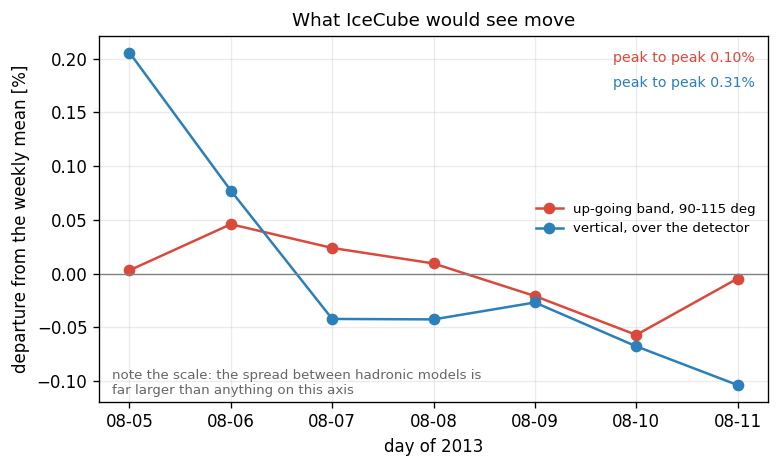

In [17]:
start = time.time()
solved = mceq.solve_batch(conditions=[
    {"zenith_deg": float(z), "density_model": detector_atmosphere(day_tables[d], d)}
    for d in week_dates for z in ZENITH_BAND])
band_rate = np.array([
    integrate_band(ZENITH_BAND, row) for row in
    rate(np.array([sum(solved.get_solution(n, k=k) for n in NU)
                   for k in range(solved.K)])).reshape(len(week_dates), -1)])
print(f"{solved.K} directions in {time.time() - start:.0f} s")

# The vertical rate over the detector, from Part 7, on the same days.
# The pole node itself, not the nearest node of the strided map grid.  One
# batch, same as above.
straight_up = mceq.solve_batch(conditions=[
    {"zenith_deg": 0.0, "density_model": dp.TabulatedAtmosphere(
        day_tables[d], coord=(SITE_LON, SITE_LAT),
        surface_elevation_m=SITE_ELEVATION_M)}
    for d in week_dates])
vertical = rate(np.array([sum(straight_up.get_solution(n, k=k) for n in NU)
                          for k in range(straight_up.K)]))

fig, ax = plt.subplots(figsize=(6.6, 4), dpi=120)
for series, label, colour in ((band_rate, "up-going band, 90-115 deg", "#d94a3d"),
                              (vertical, "vertical, over the detector", "#2c7fb8")):
    ax.plot(range(len(week_dates)), 100 * (series / series.mean() - 1), "-o",
            color=colour, label=label)
ax.axhline(0, color="0.5", lw=0.8)
ax.set_xticks(range(len(week_dates)), [d[5:] for d in week_dates])
ax.set_ylabel("departure from the weekly mean [%]")
ax.set_xlabel("day of 2013")
ax.legend(fontsize=8, frameon=False)
ax.grid(alpha=0.25)
ax.set_title("What IceCube would see move", fontsize=11)
ax.text(0.02, 0.02, "note the scale: the spread between hadronic models is\n"
        "far larger than anything on this axis",
        transform=ax.transAxes, fontsize=8, color="0.4")
for series, colour, y in ((band_rate, "#d94a3d", 0.93), (vertical, "#2c7fb8", 0.86)):
    ax.text(0.98, y, f"peak to peak {100 * (series.max() / series.min() - 1):.2f}%",
            transform=ax.transAxes, ha="right", fontsize=8.5, color=colour)
fig.tight_layout()

steady = (100 * (vertical.max() / vertical.min() - 1)
          / (100 * (band_rate.max() / band_rate.min() - 1)))
print(f"the up-going band is {steady:.0f}x steadier than the column overhead.")
print("Not because of azimuth averaging: the pole column is itself a zonal mean,")
print("since that is how Part 4 built the -90 node.  The band also averages over")
print(f"{ZENITH_BAND.size} zenith angles, i.e. impact latitudes from 89 to 40 deg S.")

## 9. What this leaves out

Events, not flux: that needs the cross section and IceCube's effective area,
folded in inside the energy integral.

The up-going neutrinos crossed thousands of kilometres of rock. MCEq neither
absorbs nor oscillates them. Absorption is negligible here, about 0.1% at
100 GeV, and only bites above 10 TeV. Oscillation does not: over a 5400 km
baseline roughly 2 to 3% of the muon neutrinos are gone at 100 GeV, which is
larger than the atmospheric effect this notebook measures.

A week is not a season. The annual swing is an order of magnitude larger than
the day-to-day motion here.

To go further: raise the map resolution and the number of zenith angles, run a
year instead of a week, and compare against `ERA5_density_spline.ipynb`, which
builds the same tables from reanalysis. Remember that ERA5 assimilates AIRS
radiances, so the two are not independent.